In [2]:
import pandas as pd
import urllib.request
import zipfile
import io
import os

# Download and unzip the dataset
url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))
zip_file.extractall("diabetes_data")

print(os.listdir("diabetes_data"))

['diabetic_data.csv', 'IDS_mapping.csv']


In [3]:
df = pd.read_csv("diabetes_data/diabetic_data.csv")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [4]:
df.isnull().sum().sort_values(ascending=False).head(15)

max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
dtype: int64

In [5]:
(df == '?').sum().sort_values(ascending=False).head(15)

weight                 98569
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
admission_type_id          0
patient_nbr                0
encounter_id               0
time_in_hospital           0
admission_source_id        0
num_lab_procedures         0
num_procedures             0
num_medications            0
dtype: int64

In [6]:
# Drop columns that are mostly missing or not clinically useful
df_clean = df.drop(columns=['weight', 'payer_code'])

# Fill remaining "?" values with "Unknown" instead of dropping rows
cols_to_fill = ['medical_specialty', 'race', 'diag_1', 'diag_2', 'diag_3']
for col in cols_to_fill:
    df_clean[col] = df_clean[col].replace('?', 'Unknown')

# Confirm no more "?" placeholders remain
print((df_clean == '?').sum().sum())
print(df_clean.shape)

0
(101766, 48)


In [7]:
print("Total encounters:", df_clean.shape[0])
print("Unique patients:", df_clean['patient_nbr'].nunique())
print("Unique encounter IDs:", df_clean['encounter_id'].nunique())

Total encounters: 101766
Unique patients: 71518
Unique encounter IDs: 101766


In [8]:
df_clean['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [9]:
df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean['readmitted_30d'].value_counts()

readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

In [10]:
def map_diagnosis(code):
    if code == 'Unknown':
        return 'Unknown'
    try:
        code_num = float(code)
    except ValueError:
        # Codes starting with V or E are special categories (supplemental/injury)
        if code.startswith('V'):
            return 'Supplemental'
        elif code.startswith('E'):
            return 'External causes'
        return 'Other'
    
    if 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif 250 <= code_num < 251:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# Apply to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_category'] = df_clean[col].apply(map_diagnosis)

# Check the result
df_clean['diag_1_category'].value_counts()

diag_1_category
Circulatory        30437
Other              16527
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Supplemental        1644
Unknown               21
External causes        1
Name: count, dtype: int64

In [10]:
age_readmission = df_clean.groupby('age')['readmitted_30d'].agg(['mean', 'count'])
age_readmission['mean'] = (age_readmission['mean'] * 100).round(2)
age_readmission.columns = ['readmission_rate_%', 'num_encounters']
print(age_readmission)

          readmission_rate_%  num_encounters
age                                         
[0-10)                  1.86             161
[10-20)                 5.79             691
[20-30)                14.24            1657
[30-40)                11.23            3775
[40-50)                10.60            9685
[50-60)                 9.67           17256
[60-70)                11.13           22483
[70-80)                11.77           26068
[80-90)                12.08           17197
[90-100)               11.10            2793


In [11]:
df_clean['prior_visits_bucket'] = pd.cut(
    df_clean['number_inpatient'],
    bins=[-1, 0, 1, 2, 100],
    labels=['0 prior', '1 prior', '2 prior', '3+ prior']
)

prior_readmission = df_clean.groupby('prior_visits_bucket', observed=True)['readmitted_30d'].agg(['mean', 'count'])
prior_readmission['mean'] = (prior_readmission['mean'] * 100).round(2)
prior_readmission.columns = ['readmission_rate_%', 'num_encounters']
print(prior_readmission)

                     readmission_rate_%  num_encounters
prior_visits_bucket                                    
0 prior                            8.44           67630
1 prior                           12.92           19521
2 prior                           17.43            7566
3+ prior                          25.66            7049


In [13]:
df_clean['med_count_bucket'] = pd.cut(
    df_clean['num_medications'],
    bins=[-1, 5, 10, 15, 20, 100],
    labels=['0-5', '6-10', '11-15', '16-20', '21+']
)

med_readmission = df_clean.groupby('med_count_bucket', observed=True)['readmitted_30d'].agg(['mean', 'count'])
med_readmission['mean'] = (med_readmission['mean'] * 100).round(2)
med_readmission.columns = ['readmission_rate_%', 'num_encounters']
print(med_readmission)

                  readmission_rate_%  num_encounters
med_count_bucket                                    
0-5                             7.48            5066
6-10                            9.45           20795
11-15                          10.91           29384
16-20                          12.17           22641
21+                            12.78           23880


In [15]:
age_readmission.sort_values('num_encounters')

,readmission_rate_%,num_encounters
age,,
[0-10),1.86,161
[10-20),5.79,691
[20-30),14.24,1657
[90-100),11.10,2793
[30-40),11.23,3775
[40-50),10.60,9685
[80-90),12.08,17197
[50-60),9.67,17256
[60-70),11.13,22483


In [16]:
cross_tab = df_clean.groupby(['age', 'prior_visits_bucket'], observed=True)['readmitted_30d'].agg(['mean', 'count'])
cross_tab['mean'] = (cross_tab['mean'] * 100).round(2)
cross_tab.columns = ['readmission_rate_%', 'num_encounters']
print(cross_tab)

                              readmission_rate_%  num_encounters
age      prior_visits_bucket                                    
[0-10)   0 prior                            1.34             149
         1 prior                            9.09              11
         2 prior                            0.00               1
[10-20)  0 prior                            3.73             510
         1 prior                            7.22              97
         2 prior                           17.95              39
         3+ prior                          15.56              45
[20-30)  0 prior                            5.49            1057
         1 prior                           17.36             242
         2 prior                           29.13             103
         3+ prior                          41.57             255
[30-40)  0 prior                            6.42            2555
         1 prior                           13.23             582
         2 prior         

In [17]:
pivot = df_clean.pivot_table(
    values='readmitted_30d',
    index='age',
    columns='prior_visits_bucket',
    aggfunc='mean',
    observed=True
)
pivot = (pivot * 100).round(2)
print(pivot)

prior_visits_bucket  0 prior  1 prior  2 prior  3+ prior
age                                                     
[0-10)                  1.34     9.09     0.00       NaN
[10-20)                 3.73     7.22    17.95     15.56
[20-30)                 5.49    17.36    29.13     41.57
[30-40)                 6.42    13.23    23.77     32.17
[40-50)                 7.01    12.55    17.71     28.30
[50-60)                 6.77    11.80    16.95     25.61
[60-70)                 8.46    13.21    17.02     25.52
[70-80)                 9.56    13.31    16.87     23.54
[80-90)                10.14    13.16    16.92     22.28
[90-100)                9.72    11.68    17.68     17.86


In [23]:
cross_tab_counts = df_clean.groupby(['age', 'prior_visits_bucket'], observed=True)['readmitted_30d'].agg(['mean', 'count'])
cross_tab_counts['mean'] = (cross_tab_counts['mean'] * 100).round(2)
cross_tab_counts.columns = ['readmission_rate_%', 'num_encounters']
print(cross_tab_counts)

                              readmission_rate_%  num_encounters
age      prior_visits_bucket                                    
[0-10)   0 prior                            1.34             149
         1 prior                            9.09              11
         2 prior                            0.00               1
[10-20)  0 prior                            3.73             510
         1 prior                            7.22              97
         2 prior                           17.95              39
         3+ prior                          15.56              45
[20-30)  0 prior                            5.49            1057
         1 prior                           17.36             242
         2 prior                           29.13             103
         3+ prior                          41.57             255
[30-40)  0 prior                            6.42            2555
         1 prior                           13.23             582
         2 prior         

In [18]:
def calculate_risk_score(row):
    score = 0
    
    # Prior inpatient visits (strongest predictor)
    if row['prior_visits_bucket'] == '3+ prior':
        score += 3
    elif row['prior_visits_bucket'] == '2 prior':
        score += 2
    elif row['prior_visits_bucket'] == '1 prior':
        score += 1
    
    # Medication count
    if row['med_count_bucket'] in ['16-20', '21+']:
        score += 2
    elif row['med_count_bucket'] in ['11-15']:
        score += 1
    
    # Age (young + prior visits is especially risky, per our cross-tab finding)
    if row['age'] in ['[20-30)', '[30-40)'] and row['prior_visits_bucket'] in ['2 prior', '3+ prior']:
        score += 2
    
    return score

df_clean['risk_score'] = df_clean.apply(calculate_risk_score, axis=1)
df_clean['risk_score'].value_counts().sort_index()

risk_score
0    19135
1    23671
2    36133
3    12542
4     5613
5     4066
6      369
7      237
Name: count, dtype: int64

In [19]:
score_validation = df_clean.groupby('risk_score')['readmitted_30d'].agg(['mean', 'count'])
score_validation['mean'] = (score_validation['mean'] * 100).round(2)
score_validation.columns = ['readmission_rate_%', 'num_encounters']
print(score_validation)

            readmission_rate_%  num_encounters
risk_score                                    
0                         6.88           19135
1                         9.02           23671
2                        10.16           36133
3                        15.05           12542
4                        19.69            5613
5                        25.82            4066
6                        29.00             369
7                        35.86             237


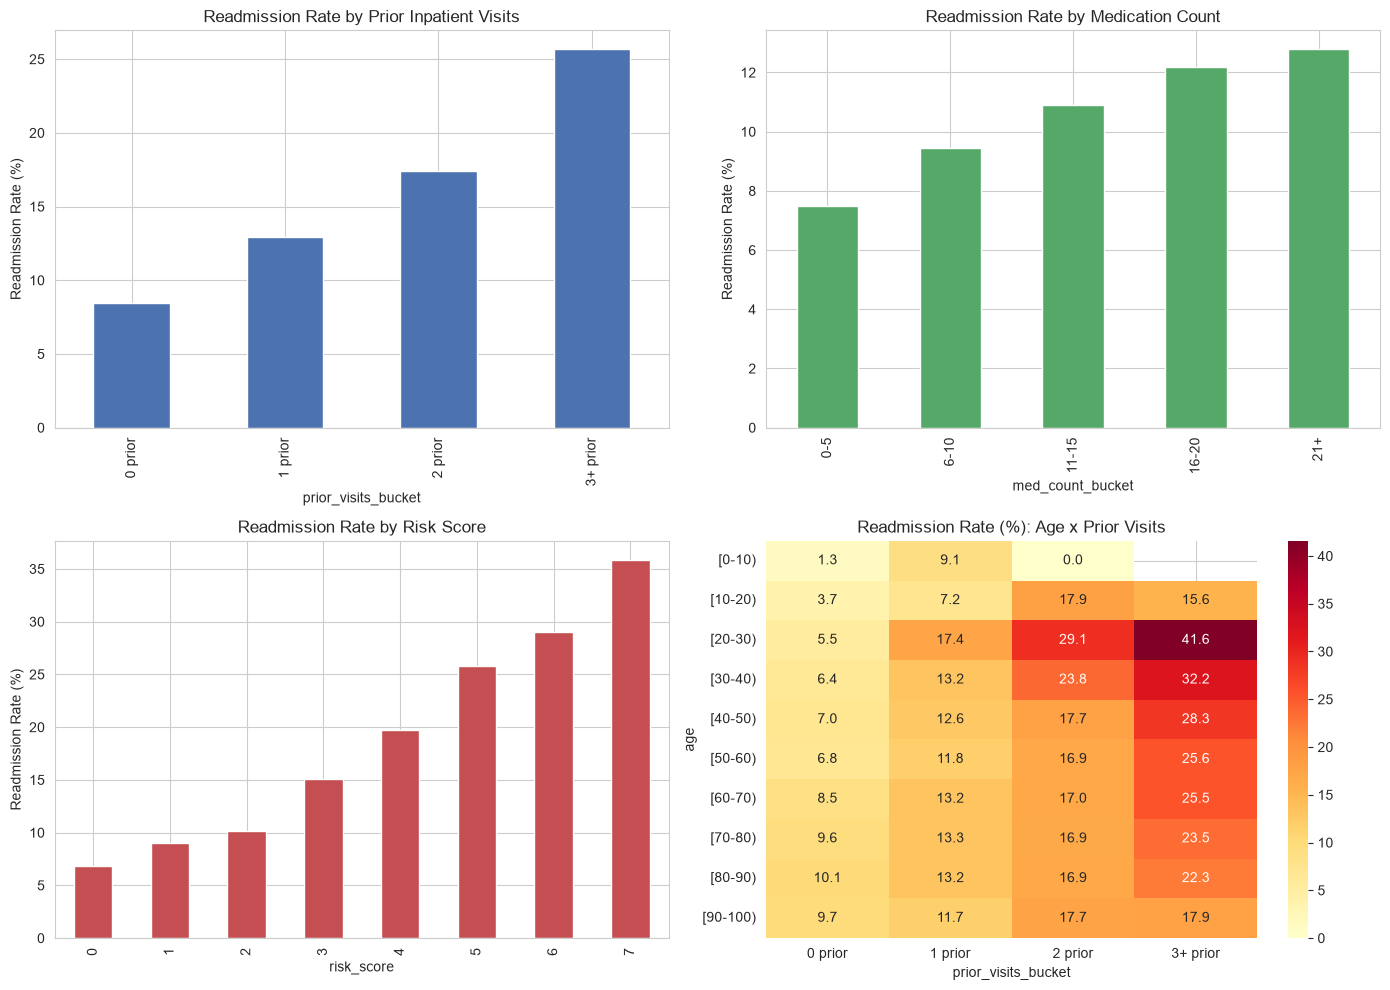

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Prior visits
prior_readmission['readmission_rate_%'].plot(kind='bar', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Readmission Rate by Prior Inpatient Visits')
axes[0,0].set_ylabel('Readmission Rate (%)')

# Chart 2: Medication count
med_readmission['readmission_rate_%'].plot(kind='bar', ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Readmission Rate by Medication Count')
axes[0,1].set_ylabel('Readmission Rate (%)')

# Chart 3: Risk score validation
score_validation['readmission_rate_%'].plot(kind='bar', ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('Readmission Rate by Risk Score')
axes[1,0].set_ylabel('Readmission Rate (%)')

# Chart 4: Heatmap of age x prior visits
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Readmission Rate (%): Age x Prior Visits')

plt.tight_layout()
plt.savefig('outputs/key_findings.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
with pd.ExcelWriter('outputs/readmission_analysis_summary.xlsx', engine='openpyxl') as writer:
    age_readmission.to_excel(writer, sheet_name='By Age')
    prior_readmission.to_excel(writer, sheet_name='By Prior Visits')
    med_readmission.to_excel(writer, sheet_name='By Medication Count')
    pivot.to_excel(writer, sheet_name='Age x Prior Visits')
    score_validation.to_excel(writer, sheet_name='Risk Score Validation')

print("Excel file saved successfully")

Excel file saved successfully
